In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sushantkr878/telco-customer-churn-dataset/Telco Customer Churn Dataset.csv


In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sushantkr878/telco-customer-churn-dataset/Telco Customer Churn Dataset.csv


# Step 1 — Problem Framing

Business Objective

Predict which customers are likely to churn (cancel their service) so that the retention team can proactively target them.

Cost Analysis
1. Error Type	Meaning	Cost
2. False Negative (FN)	Customer will churn, but the model predicts they will not	High — customer loss results in         revenue loss

   False Positive (FP)	Customer will not churn, but the model predicts they will	Low — retention team sends an
   unnecessary offer


Conclusion

1. False Negatives are more expensive, so Recall should be prioritized. However, F1-score should also be tracked because    too many false positives waste budget.


Since the dataset is imbalanced, avoid relying on Accuracy. Use PR-AUC and F1-score as primary metrics.


Baseline


Use a majority-class predictor that predicts every customer as "No Churn".

1. If 73% of customers are non-churners, this baseline achieves 73% accuracy without learning anything.
2. This becomes the minimum benchmark.
3. The baseline recall for churners is 0%.

# Step 2 — Get the Data

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
from scipy import stats

In [4]:
df = pd.read_csv('/kaggle/input/datasets/sushantkr878/telco-customer-churn-dataset/Telco Customer Churn Dataset.csv')

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step 3 — Initial EDA (Before Splitting)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.drop(columns=['customerID'], inplace=True)

In [9]:
df['TotalCharges'].value_counts()

TotalCharges
           11
20.2       11
19.75       9
20.05       8
19.9        8
           ..
130.15      1
3211.9      1
7843.55     1
2196.3      1
197.4       1
Name: count, Length: 6531, dtype: int64

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors='coerce')

In [11]:
print(df['TotalCharges'].isnull().sum())

11


In [12]:
# Target distribution
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

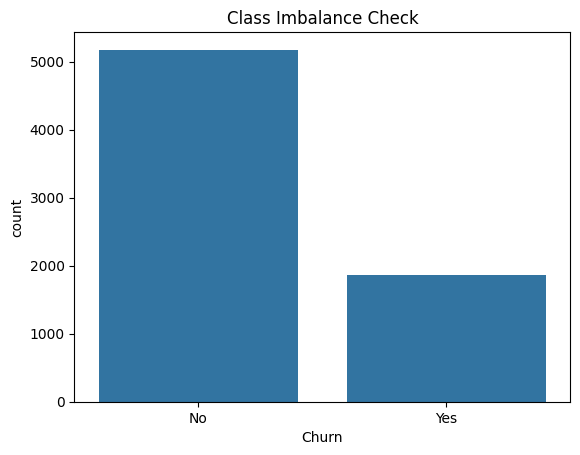

In [13]:
sns.countplot(x='Churn', data=df)
plt.title("Class Imbalance Check")
plt.show()

In [14]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

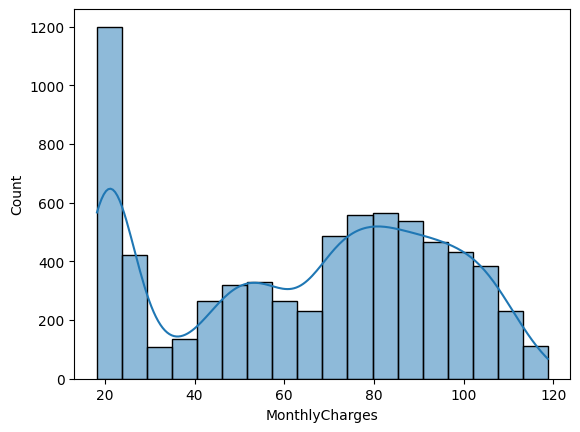

In [15]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.show()

# Step 4 — Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [17]:
X_train.shape

(5634, 19)

In [18]:
X_test.shape

(1409, 19)

# Step 5 — Detailed EDA (Train Data Only)

In [19]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65
3151,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55
4860,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35
3867,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70
3810,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55


In [20]:
X_train.shape

(5634, 19)

In [21]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 1

In [22]:
X_train['gender'].value_counts(dropna=False)

gender
Male      2833
Female    2801
Name: count, dtype: int64

In [23]:
X_train.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        8
dtype: int64

In [24]:
X_train.duplicated().sum()

np.int64(26)

In [25]:
dup_percent = (
    X_train.duplicated().sum()
    / len(X_train)
) * 100

print(f"Duplicate percentage: {dup_percent:.2f}%")

Duplicate percentage: 0.46%


In [26]:
duplicates = X_train[
    X_train.duplicated()
]

duplicates.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
4789,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Mailed check,71.10,71.10
1049,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65
5170,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65
1938,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.90,20.90
2713,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45


In [27]:
X_train[
    X_train.duplicated(
        keep=False
    )
].sort_values(
    by=X_train.columns.tolist()
)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
684,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Mailed check,71.10,71.10
4789,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Mailed check,71.10,71.10
6491,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20
6764,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20
6267,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10
4495,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10
5759,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15
5522,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15
1736,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.50,19.50
4172,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.50,19.50


In [28]:
dup_idx = X_train[X_train.duplicated(keep=False)].index
y_train.loc[dup_idx].value_counts()

Churn
1    28
0    20
Name: count, dtype: int64

These aren't data-entry errors; they're different customers (different index/customerID) who genuinely happen to have the same profile (same tenure, plan, charges). With categorical features + tenure=1, coincidental matches are expected and realistic — that's real signal, not noise.

### FInal decision is i will not remove them .

# Encoding Strategy Decision

In [29]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 1

In [30]:
X_train.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65
3151,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55
4860,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35
3867,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70
3810,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55


In [31]:
# i will apply one hot encoding on gender . (is_male = 0 or 1)

In [32]:
print(X_train['OnlineSecurity'].unique())

['No' 'Yes' 'No internet service']


In [33]:
# in the OnlineSecurity i will apply one hot encoding

In [34]:
# for the column Partner ,Dependents,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,
#   StreamingTV	,StreamingMovies,PaperlessBilling, Map them with yes and no with 1 and 0 . 

In [35]:
X_train['MultipleLines'].value_counts()

MultipleLines
No                  2685
Yes                 2390
No phone service     559
Name: count, dtype: int64

In [36]:
# i will apply one hot encoding in the MultipleLines column . 

In [37]:
X_train['InternetService'].value_counts()

InternetService
Fiber optic    2483
DSL            1937
No             1214
Name: count, dtype: int64

In [38]:
# i will apply one hot encoding in the InternetService column . 

In [39]:
X_train['Contract'].value_counts()

Contract
Month-to-month    3102
Two year          1359
One year          1173
Name: count, dtype: int64

In [40]:
# in this Contract column i will apply ordinal encoding in this column . 

In [41]:
X_train['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             1891
Mailed check                 1286
Bank transfer (automatic)    1244
Credit card (automatic)      1213
Name: count, dtype: int64

In [42]:
# i will apply one hot encoding in this PaymentMethod column . 

# Missing Values Analysis

In [43]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 1

Totalcharges is float but it is showing object , check it and convert it into int . 

In [44]:
print(df['TotalCharges'].dtype)

float64


In [45]:
X_train['TotalCharges'].value_counts(dropna = False)

TotalCharges
20.20      9
NaN        8
19.65      7
45.30      7
20.05      6
          ..
4812.75    1
3068.60    1
3252.00    1
6697.35    1
414.10     1
Name: count, Length: 5276, dtype: int64

In [46]:
# at here there is no null values . 

In [47]:
# df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors='coerce') i will do this before train test split

In [48]:
X_train['TotalCharges'] = pd.to_numeric(X_train['TotalCharges'], errors='coerce')

In [49]:
df['TotalCharges'].dtypes

dtype('float64')

In [50]:
print(df['TotalCharges'].isnull().sum())

11


In [51]:
# now lets find if the data is mcar , mar or mnar then i will conclude how to fill it . 

In [52]:
missing_mask = df['TotalCharges'].isnull()

df[missing_mask][['tenure', 'MonthlyCharges', 'Contract']]

,tenure,MonthlyCharges,Contract
488,0,52.55,Two year
753,0,20.25,Two year
936,0,80.85,Two year
1082,0,25.75,Two year
1340,0,56.05,Two year
3331,0,19.85,Two year
3826,0,25.35,Two year
4380,0,20.00,Two year
5218,0,19.70,One year
6670,0,73.35,Two year


In [53]:
print(df[missing_mask]['tenure'].unique())

[0]


Missing Value Analysis Note — TotalCharges Column

Finding:

The TotalCharges column had 11 missing values (originally stored as blank/space strings, which converted to NaN after pd.to_numeric()).



Investigation:

Checked the other observed columns (tenure, Contract) for the rows with missing TotalCharges.

Result: All 11 missing rows had tenure = 0, and most of them had long-term contracts (Two year or One year).



Interpretation:

These are new customers whose billing cycle hasn't started yet (tenure = 0 means less than a month with the company), so no total charge amount has been generated for them yet. The missingness is not random — it is explained by another observed variable (tenure), and reinforced by a second observed variable (Contract type of these customers).
Classification: MAR (Missing At Random)
The missingness of TotalCharges does not depend on its own unseen value; it depends on other observed columns in the dataset (tenure, and to some extent Contract). This rules out MNAR (which would require the missingness to depend on the value of TotalCharges itself) and MCAR (which would require no relationship with any other variable at 
all).



Imputation decision:

Since domain logic explains the missingness (tenure = 0 → no bill generated yet), the most appropriate fix is to set TotalCharges = 0 for these rows, rather than using 

median/mean imputation, since a new customer's total charge is genuinely 0, not "unknown."


### The conclusion is this missing value is completely missing at random MAR

In [54]:
# this means for the new customer , no bills were made . 

In [55]:
X_train['TotalCharges'].skew()

np.float64(0.9475162595460518)

### Decision - I will fill it with zero 

Missing TotalCharges values all belong to customers with tenure = 0 (new customers, no bill generated yet). So the true value is actually 0, not an unknown number to estimate. Median/mean imputation is for unknown-but-real values — doesn't apply here since we know the real value via domain logic. Hence, fill with 0, not median/mean.

## Outliers Detection

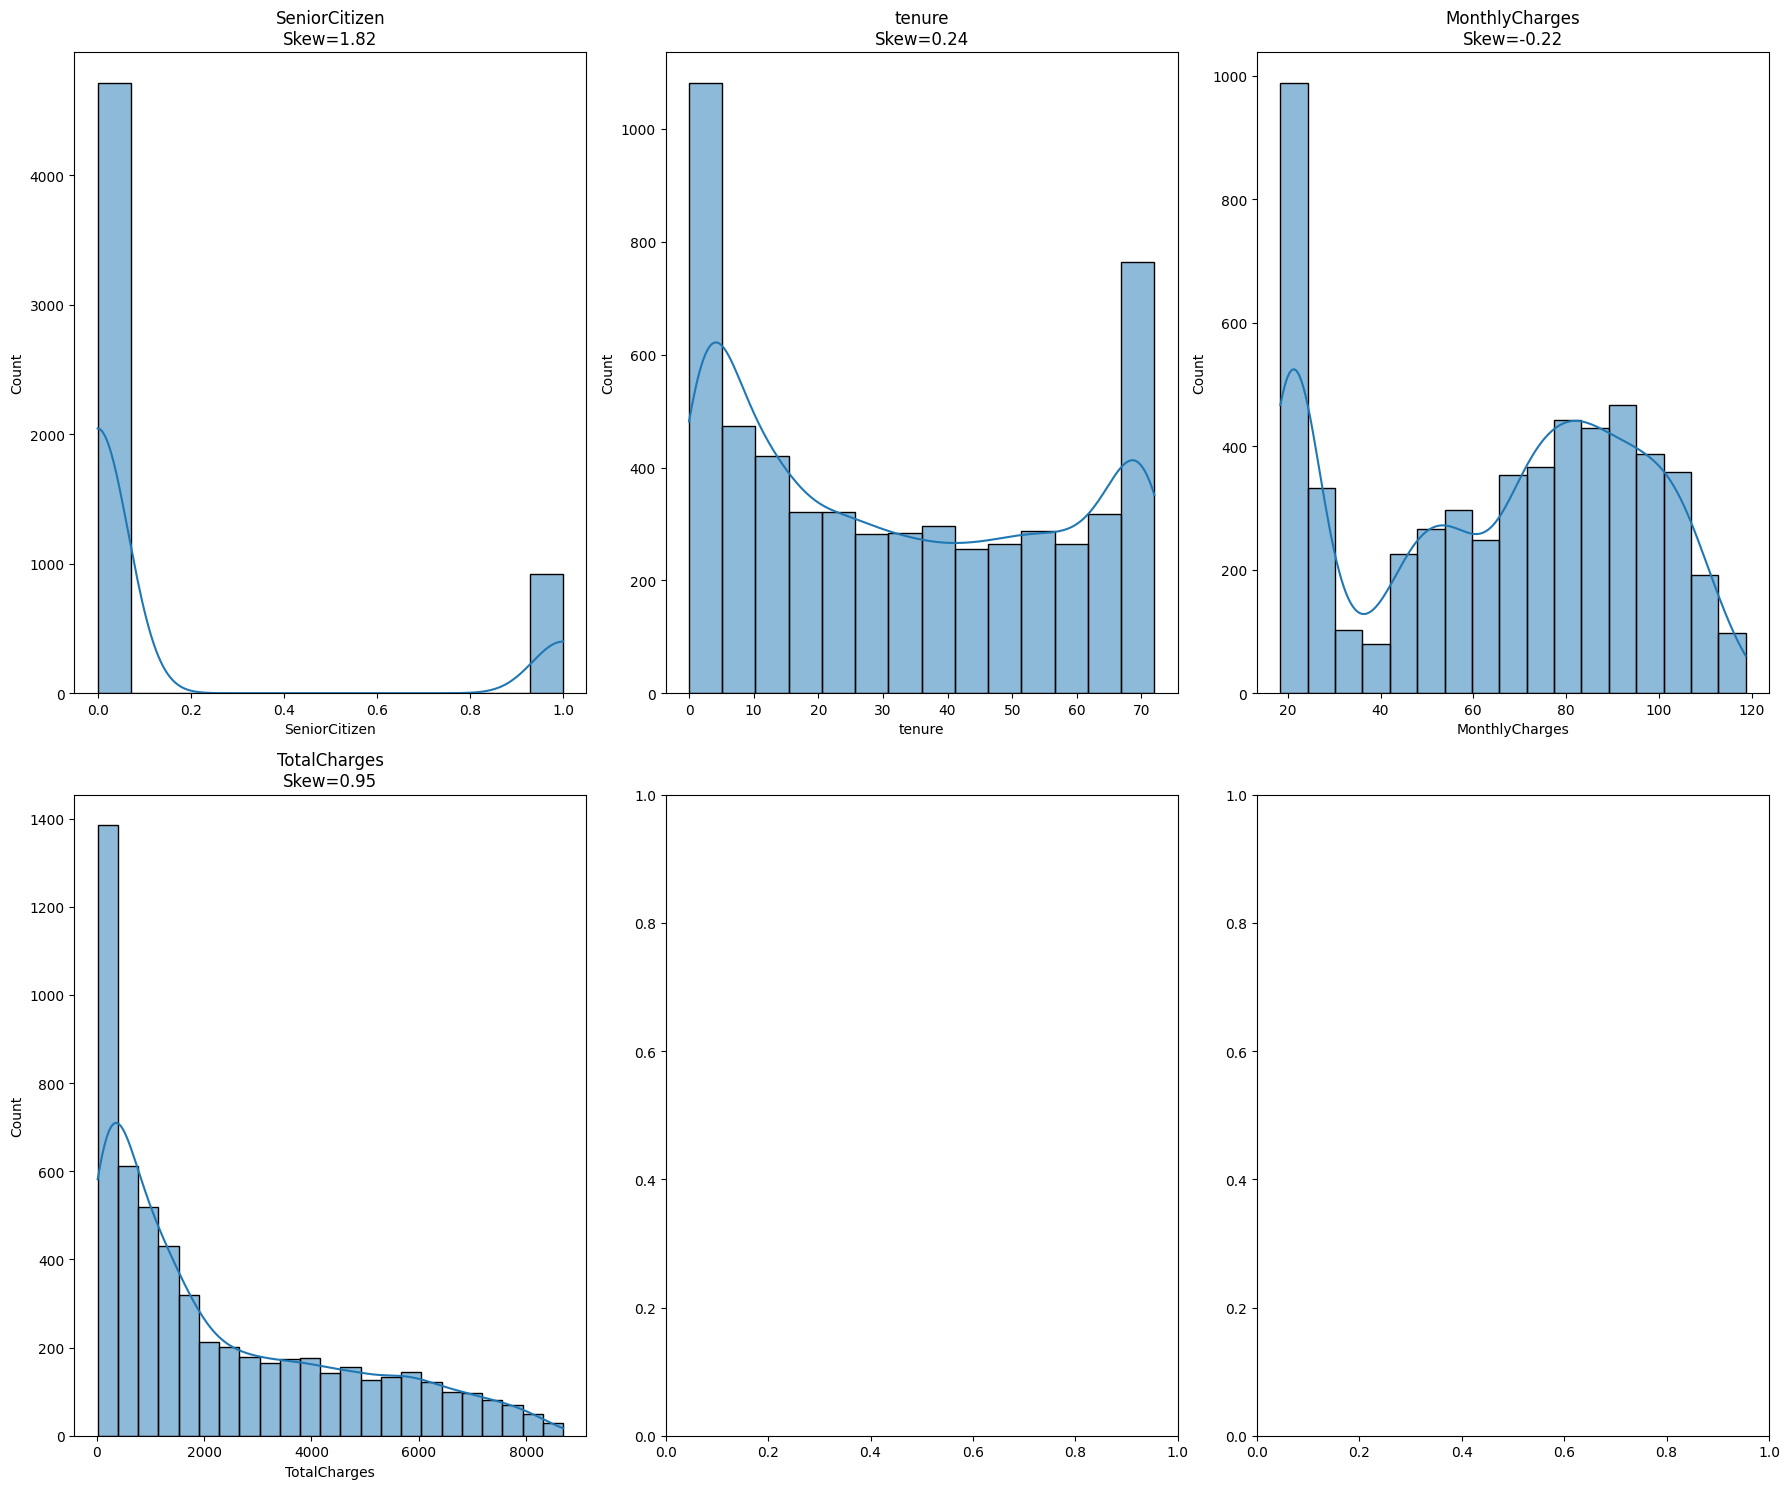

In [56]:
num_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

fig, axes = plt.subplots(
    nrows=(len(num_cols)+2)//3,
    ncols=3,
    figsize=(18,15)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train[col],
        kde=True,
        ax=axes[i]
    )

    skew = X_train[col].skew()

    axes[i].set_title(
        f'{col}\nSkew={skew:.2f}'
    )

plt.tight_layout()
plt.show()

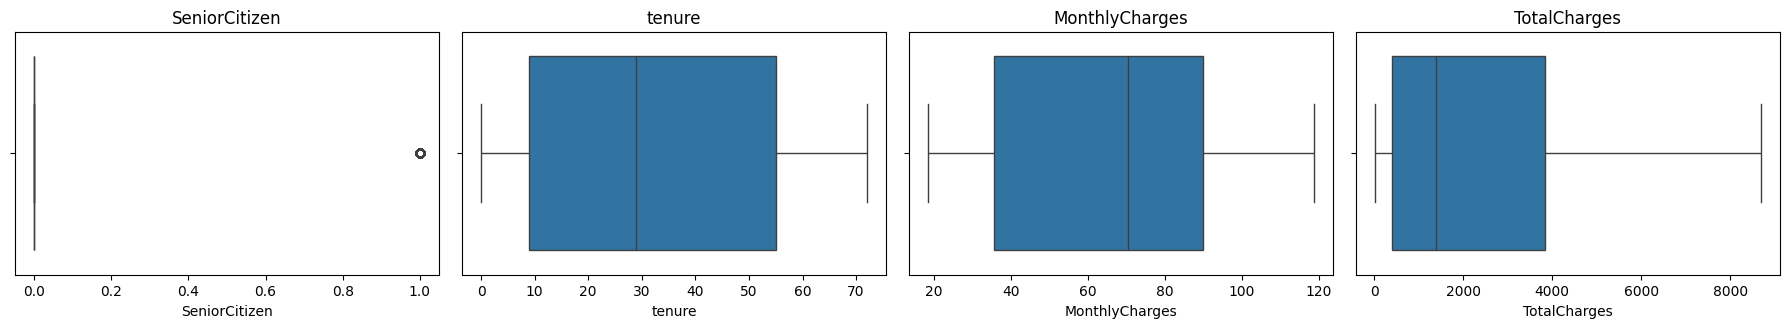

In [57]:
plt.figure(figsize=(18,12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4,4,i)
    sns.boxplot(x=X_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [58]:
skewness = X_train[num_cols].skew()

highly_skewed = skewness[
    abs(skewness) > 0.5
].sort_values(ascending=False)

print(highly_skewed)

SeniorCitizen    1.822318
TotalCharges     0.947516
dtype: float64


In [59]:
X_train['SeniorCitizen'].describe()

count    5634.000000
mean        0.163294
std         0.369667
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: SeniorCitizen, dtype: float64

In [60]:
print(X_train['SeniorCitizen'].unique())

[0 1]


In [61]:
# 'SeniorCitizen' has only 0 and 1 , later i will convert it from one hot encoding 

In [62]:
X_train['TotalCharges'].describe()

count    5626.000000
mean     2302.604266
std      2279.173176
min        18.850000
25%       407.275000
50%      1398.125000
75%      3838.612500
max      8684.800000
Name: TotalCharges, dtype: float64

In [63]:
X_train['TotalCharges'].value_counts(dropna = False)

TotalCharges
20.20      9
NaN        8
19.65      7
45.30      7
20.05      6
          ..
4812.75    1
3068.60    1
3252.00    1
6697.35    1
414.10     1
Name: count, Length: 5276, dtype: int64

In [64]:
# since i have decided to fill it with 0 , and i want to use models like Random Forest, XGBoost , so skip the process of reducing its skewness . 

In [65]:
X_train.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65
3151,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55
4860,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35
3867,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70
3810,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55
2666,Male,0,No,Yes,66,Yes,No,DSL,No,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),79.50,5196.10
2645,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),19.80,19.80
189,Female,0,Yes,No,40,Yes,Yes,DSL,No,Yes,No,No,No,No,Month-to-month,No,Credit card (automatic),56.60,2379.10
5767,Female,0,Yes,No,65,Yes,No,DSL,No,No,No,Yes,Yes,No,Two year,Yes,Credit card (automatic),59.80,3808.20
2257,Female,0,No,No,60,Yes,Yes,DSL,No,No,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),80.55,4847.05


# Step 6 — Preprocessing Pipeline

## Step 1 — Cleanup (Before Pipeline , once)

In [66]:
cols_with_redundant_no = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_with_redundant_no:
    X_train[col] = X_train[col].replace('No internet service', 'No')
    X_test[col] = X_test[col].replace('No internet service', 'No')

In [67]:
# replacing the No internet service with no 

## Step 2 — Column Groups Define

In [68]:
onehot_binary_col = ['gender']  


binary_cols = ['Partner', 'Dependents', 'PhoneService', 'OnlineSecurity', # columns having Yes and No
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling']


onehot_cols = ['MultipleLines', 'InternetService', 'PaymentMethod']

ordinal_col = ['Contract']

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

passthrough_cols = ['SeniorCitizen']  

## Step 3 — Pipeline

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# 1. gender -> single 0/1 column
gender_transformer = OneHotEncoder(drop='if_binary')

# 2. Yes/No  binary columns -> OrdinalEncoder - 0/1
binary_transformer = OrdinalEncoder(
    categories=[['No', 'Yes']] * len(binary_cols),
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

# 3. Multi-category nominal columns -> one-hot
onehot_transformer = OneHotEncoder(handle_unknown='ignore')

# 4. Contract -> ordinal (natural order)
ordinal_transformer = OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']])

# 5. Numeric -> only NaN fill , NO scaling for tree-based models.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])


In [70]:
preprocessor = ColumnTransformer(transformers=[
    ('gender', gender_transformer, onehot_binary_col),
    ('binary', binary_transformer, binary_cols),
    ('onehot', onehot_transformer, onehot_cols),
    ('ordinal', ordinal_transformer, ordinal_col),
    ('num', numeric_transformer, num_cols),
    ('passthrough', 'passthrough', passthrough_cols)
])

In [71]:
from sklearn import set_config
set_config(display='diagram')

preprocessor  

ColumnTransformer(transformers=[('gender', OneHotEncoder(drop='if_binary'),
                                 ['gender']),
                                ('binary',
                                 OrdinalEncoder(categories=[['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes']],
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['Partner', 'Dependents', 'PhoneService',
                                  'Onl...
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['MultipleLines', 'InternetService',
                                  'PaymentMethod']),
                                ('ordinal',
                                 OrdinalEncoder(categories=[['Month-to-month',
                                                             'One year',
                                                             'Two year']]),
                                 ['Contract']),
                                ('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value=0,
                                                                strategy='constant'))]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('passthrough', 'passthrough',
                                 ['SeniorCitizen'])])

In [72]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [73]:
feature_names = preprocessor.get_feature_names_out()
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_train_transformed_df.head()

,gender__gender_Male,binary__Partner,binary__Dependents,binary__PhoneService,binary__OnlineSecurity,binary__OnlineBackup,binary__DeviceProtection,binary__TechSupport,binary__StreamingTV,binary__StreamingMovies,...,onehot__InternetService_No,onehot__PaymentMethod_Bank transfer (automatic),onehot__PaymentMethod_Credit card (automatic),onehot__PaymentMethod_Electronic check,onehot__PaymentMethod_Mailed check,ordinal__Contract,num__tenure,num__MonthlyCharges,num__TotalCharges,passthrough__SeniorCitizen
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,35.0,49.20,1701.65,0.0
1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,15.0,75.10,1151.55,0.0
2,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,13.0,40.55,590.35,0.0
3,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,2.0,26.0,73.50,1905.70,0.0
4,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,44.55,44.55,0.0


since it is a Classification problem , focus on 

1. Accuracy, Precision, Recall, F1-score .
2. ROC-AUC, PR-AUC .
3. Log Loss (probability quality — how much confident and calibrated is the model)
4. Confusion Matrix (error breakdown)
5. Matthews Correlation Coefficient (MCC) —  A Realiable metric for imbalanced data . 

# Model Training 

In [74]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Class imbalance ratio (churn ~27%) 
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [75]:
# 1. Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('gender',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['gender']),
                                                 ('binary',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Partner',...
                                                  OrdinalEncoder(categories=[['Month-to-month',
                                                                              'One '
                                                                              'year',
                                                                              'Two '
                                                                              'year']]),
                                                  ['Contract']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('passthrough', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [76]:
# 2. XGBoost 
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train) 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('gender',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['gender']),
                                                 ('binary',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Partner',...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [77]:
# 3. LightGBM 
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))
])

lgbm_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002446 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('gender',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['gender']),
                                                 ('binary',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Partner',...
                                                  OrdinalEncoder(categories=[['Month-to-month',
                                                                              'One '
                                                                              'year',
                                                                              'Two '
                                                                              'year']]),
                                                  ['Contract']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('passthrough', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('model',
                 LGBMClassifier(random_state=42,
                                scale_pos_weight=np.float64(2.768561872909699)))])

# Step 9 — Cross-Validation & Hyperparameter Tuning

In [78]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgbm_pipeline
}

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1')
    cv_results[name] = scores
    print(f"{name}: mean F1 = {scores.mean():.3f}, std = {scores.std():.3f}, all folds = {np.round(scores,3)}")

Random Forest: mean F1 = 0.537, std = 0.026, all folds = [0.515 0.518 0.583 0.519 0.55 ]
XGBoost: mean F1 = 0.601, std = 0.018, all folds = [0.593 0.571 0.615 0.606 0.622]
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000508 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265365 -> initscore=-1.018268
[LightGBM] [Info] Start training from score -1.018268
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000951 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 630
[LightGBM]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000552 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265365 -> initscore=-1.018268
[LightGBM] [Info] Start training from score -1.018268
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000505 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 26
[LightGBM] [Info] [binary:

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 3312
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000637 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 4508, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265306 -> initscore=-1.018570
[LightGBM] [Info] Start training from score -1.018570
LightGBM: mean F1 = 0.626, std = 0.009, all folds = [0.629 0.612 0.62  0.63  0.639]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


📊 Model Performance Summary

| Model         | Mean F1 Score | Standard Deviation |
| ------------- | ------------: | -----------------: |
| Random Forest |         0.537 |              0.026 |
| XGBoost       |         0.601 |              0.018 |
| LightGBM      |     **0.626** |          **0.009** |


LightGBM wins — highest F1 and most least std (most stable across folds).
                                               
This model is selected for tunning. 

In [79]:
# LightGBM tuning (best CV model)
param_dist = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [3, 5, 7, -1],          # -1 = no limit
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__num_leaves': [20, 31, 50, 70],
    'model__subsample': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    lgbm_pipeline, param_dist, n_iter=20, cv=skf,
    scoring='f1', random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV F1:", search.best_score_)

best_model = search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265365 -> initscore=-1.018268
[LightGBM] [Info] Start training from score -1.018268
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

...


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

# Step 10 — Error Analysis

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


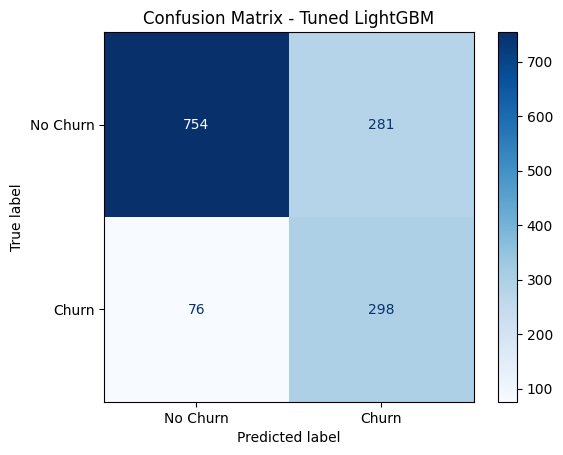

              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.51      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [80]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(cmap='Blues')
plt.title("Confusion Matrix - Tuned LightGBM")
plt.show()

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

In [81]:
# Here F1-score is most important . 

# 📌 Conclusion — Final Model Evaluation (Tuned LightGBM)

The final **LightGBM** model was evaluated on the held-out test set, which was kept completely unseen throughout feature engineering, model selection, and hyperparameter tuning. This ensures that the reported performance provides an unbiased estimate of the model's real-world predictive capability.

## 📊 Key Performance Metrics (Churn Class)

| Metric        |    Score | Interpretation                                                                                   |
| ------------- | -------: | ------------------------------------------------------------------------------------------------ |
| **Recall**    | **0.80** | The model correctly identifies **80% of customers who will actually churn**.                     |
| **Precision** | **0.51** | Of all customers predicted to churn, **51% genuinely churn**.                                    |
| **F1-score**  | **0.63** | Indicates a reasonable balance between precision and recall.                                     |
| **Accuracy**  | **0.75** | Reported for completeness, but not used as the primary evaluation metric due to class imbalance. |

## 💼 Business Alignment

As established during the problem formulation stage, **False Negatives** (failing to identify a customer who will churn) are significantly more costly than **False Positives** (incorrectly flagging a loyal customer). Losing a customer represents a direct loss of revenue, whereas an unnecessary retention campaign incurs a comparatively smaller cost.

The model's **high recall of 0.80** directly aligns with this business objective by successfully identifying the majority of at-risk customers. This performance is achieved by accepting a higher number of false alarms, resulting in a lower precision score, which is an acceptable trade-off given the business priorities.

## 📈 Comparison with Baseline

A naive majority-class baseline model that predicts **"No Churn"** for every customer would achieve approximately **0% recall for the churn class**, making it ineffective for churn prevention.

In contrast, the tuned LightGBM model achieves a **recall of 80%**, representing a substantial and practically meaningful improvement over the baseline approach.

## ⚠️ Limitation

The model's precision score of **0.51** indicates that approximately half of the customers identified as potential churners will not actually churn. While this false-positive rate is acceptable under the current cost assumptions, it should be clearly communicated to business stakeholders so that retention budgets and intervention strategies can be planned accordingly.

## 🏆 Final Conclusion

The tuned **LightGBM** model successfully meets the primary business objective of maximizing churn detection while maintaining a reasonable balance between precision and recall. Given the higher business cost associated with missed churners, the model's strong recall performance makes it an appropriate and effective solution for customer churn prediction.


# Step 11 — Final Evaluation 

In [82]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, average_precision_score)

# comparison of all models.
final_results = []

for name, pipe in pipelines.items():
    y_pred_i = pipe.predict(X_test)
    y_prob_i = pipe.predict_proba(X_test)[:, 1]
    final_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred_i),
        'Precision': precision_score(y_test, y_pred_i),
        'Recall': recall_score(y_test, y_pred_i),
        'F1': f1_score(y_test, y_pred_i),
        'ROC-AUC': roc_auc_score(y_test, y_prob_i),
        'PR-AUC': average_precision_score(y_test, y_prob_i)
    })

# Tuned LightGBM 
y_prob_best = best_model.predict_proba(X_test)[:, 1]
final_results.append({
    'Model': 'Tuned LightGBM',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob_best),
    'PR-AUC': average_precision_score(y_test, y_prob_best)
})

results_df = pd.DataFrame(final_results).sort_values('F1', ascending=False)
print(results_df.to_string(index=False))

         Model  Accuracy  Precision   Recall       F1  ROC-AUC   PR-AUC
Tuned LightGBM  0.746629   0.514680 0.796791 0.625393 0.844748 0.661291
      LightGBM  0.753016   0.524621 0.740642 0.614191 0.832799 0.650091
       XGBoost  0.745919   0.517021 0.649733 0.575829 0.817400 0.624106
 Random Forest  0.783534   0.614618 0.494652 0.548148 0.824989 0.617971


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [83]:
# # Overfitting check - train vs test F1
# y_train_pred = best_model.predict(X_train)
# train_f1 = f1_score(y_train, y_train_pred)
# test_f1 = f1_score(y_test, y_pred)

# print(f"Train F1: {train_f1:.3f}")
# print(f"Test F1: {test_f1:.3f}")
# print(f"Gap: {train_f1 - test_f1:.3f}")

In [84]:
# # Baseline comparison - proof of improvement
# baseline_pred = np.zeros(len(y_test))
# print("Baseline Recall:", recall_score(y_test, baseline_pred))   # 0.0 aayega
# print("Baseline F1:", f1_score(y_test, baseline_pred))           # 0.0 aayega
# print("Model Recall:", recall_score(y_test, y_pred))
# print("Model F1:", f1_score(y_test, y_pred))

In [85]:
# Training predictions
y_train_pred = best_model.predict(X_train)
y_train_prob = best_model.predict_proba(X_train)[:, 1]   # roc_auc ke liye probability chahiye

# Training Metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_prob)   # y_train_prob use kiya, y_train_pred nahi

print(f"Train Accuracy:  {train_accuracy:.3f}")
print(f"Train F1:        {train_f1:.3f}")
print(f"Train Precision: {train_precision:.3f}")
print(f"Train Recall:    {train_recall:.3f}")
print(f"Train ROC-AUC:   {train_roc_auc:.3f}")

Train Accuracy:  0.764
Train F1:        0.655
Train Precision: 0.535
Train Recall:    0.843
Train ROC-AUC:   0.875


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Reading the Curve: The closer the curve is to the top-left corner (and the farther it is from the red dashed line), the better the model's performance.

1. Churner = customers who will leave the company . 
2. non-churner  = customers who will not leave the company 